# DreamGuard - Survey Analysis

Analyzes `data/survey_responses.csv` collected via Google Forms.

**Conditions ranked in the survey:**
- Meta Guardian Grid
- Window
- Window + Detection
- Depth Bubble

**Survey structure:**
- Demographics & prior VR experience
- General task ratings (interruption sensitivity, cognitive demand, engagement)
- Per-condition Likert items (awareness, immersion, disruption, trust, familiarity)
  - Section A: Guardian Grid (optional — skip if it never appeared)
  - Sections B–D: the three other conditions in counterbalanced order
- Rankings across all four conditions (safety, disruption, trust)
- Free-text responses

In [37]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

warnings.filterwarnings('ignore')
%matplotlib inline

NB_DIR   = Path('.').resolve()
DATA_DIR = NB_DIR.parent / 'data'
OUT_DIR  = DATA_DIR / 'analysis'
OUT_DIR.mkdir(exist_ok=True)

SURVEY_CSV = DATA_DIR / 'survey_responses.csv'
assert SURVEY_CSV.exists(), f'Not found: {SURVEY_CSV}'
print(f'Loading: {SURVEY_CSV}')

Loading: F:\Unity\Projects\DreamGuard\data\survey_responses.csv


## Load & label columns

In [38]:
raw = pd.read_csv(SURVEY_CSV)
print(f'{len(raw)} response(s), {len(raw.columns)} columns')

# ── Rename columns to short, stable names ────────────────────────────────────
# Demographics
DEMO_COLS = {
    raw.columns[0]:  'timestamp',
    raw.columns[1]:  'age',
    raw.columns[2]:  'gender',
    raw.columns[3]:  'vr_frequency',
    raw.columns[4]:  'used_quest',
    raw.columns[5]:  'physical_hazard_history',
}
# General task ratings
TASK_COLS = {
    raw.columns[6]:  'interruption_sensitivity',
    raw.columns[7]:  'cognitive_demand',
    raw.columns[8]:  'engagement',
    raw.columns[9]:  'guardian_grid_appeared',
}
# Per-condition Likert items — 6 columns per section, 4 sections
# Section A = Guardian Grid (optional; shown only if it appeared)
# Sections B, C, D = other three conditions in survey order
LIKERT_ITEMS = ['aware', 'immersed', 'disrupted', 'trust', 'unfamiliar', 'freetext']
SECTIONS = ['guardian_grid', 'cond_b', 'cond_c', 'cond_d']
COND_COLS = {}
base = 10
for sec in SECTIONS:
    for i, item in enumerate(LIKERT_ITEMS):
        COND_COLS[raw.columns[base + i]] = f'{sec}_{item}'
    base += 6

# Rankings — 4 systems × 3 dimensions
# Use partial keywords that match the actual Google Form column text:
#   safety    → "safe"     ("how safe they made you feel")
#   disruption → "disrupt" ("how much they disrupted your immersion")
#   trust     → "trust"    ("how much you trusted them")
CONDITIONS = ['Meta Guardian Grid', 'Window', 'Window + Detection', 'Depth Bubble']
DIM_KEYWORDS = {'safety': 'safe', 'disruption': 'disrupt', 'trust': 'trust'}
RANK_COLS = {}
for cond in CONDITIONS:
    for dim in ['safety', 'disruption', 'trust']:
        kw = DIM_KEYWORDS[dim]
        col = [c for c in raw.columns if f'[{cond}]' in c and kw in c.lower()]
        if col:
            RANK_COLS[col[0]] = f'rank_{dim}_{cond.lower().replace(" ", "_").replace("+", "plus")}'

# Final free-text
EXTRA_COLS = {
    raw.columns[-2]: 'most_want_system',
    raw.columns[-1]: 'surprising_room',
}

rename_map = {**DEMO_COLS, **TASK_COLS, **COND_COLS, **RANK_COLS, **EXTRA_COLS}
df = raw.rename(columns=rename_map)
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Convert ordinal rank strings like "1st", "2nd" to integers
ORD_MAP = {'1st': 1, '2nd': 2, '3rd': 3, '4th': 4}
rank_short_cols = [c for c in df.columns if c.startswith('rank_')]
for c in rank_short_cols:
    df[c] = df[c].map(ORD_MAP).astype('Int64')

# Likert numeric cols (exclude freetext columns)
likert_cols = [c for c in df.columns
               for item in ['aware', 'immersed', 'disrupted', 'trust', 'unfamiliar']
               if c.endswith(f'_{item}')]
for c in likert_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print(f'Columns mapped. {len(df)} response(s).')
print(f'Rank columns found: {rank_short_cols}')
display(df[list(DEMO_COLS.values()) + list(TASK_COLS.values())[:3]])

3 response(s), 54 columns
Columns mapped. 3 response(s).
Rank columns found: ['rank_safety_meta_guardian_grid', 'rank_safety_window', 'rank_safety_window_plus_detection', 'rank_safety_depth_bubble', 'rank_disruption_meta_guardian_grid', 'rank_disruption_window', 'rank_disruption_window_plus_detection', 'rank_disruption_depth_bubble', 'rank_trust_meta_guardian_grid', 'rank_trust_window', 'rank_trust_window_plus_detection', 'rank_trust_depth_bubble']


,timestamp,age,gender,vr_frequency,used_quest,physical_hazard_history,interruption_sensitivity,cognitive_demand,engagement
0,2026-05-08 22:27:44,28,Male,Weekly or more frequently,Yes,Yes,6,4,4
1,2026-05-09 13:17:17,30,Male,A few times total,Yes,No,6,1,6
2,2026-05-09 16:23:05,26,Male,Monthly,Yes,Yes,6,2,5


## Demographics

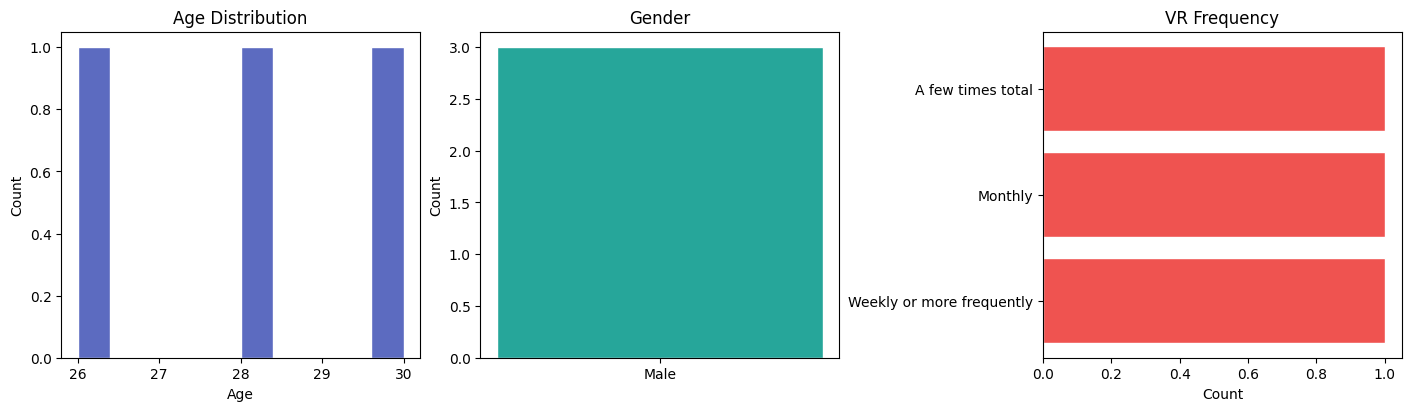

Prior Quest use: {'Yes': 3}
Physical hazard history: {'Yes': 2, 'No': 1}


In [39]:
if len(df) < 2:
    print('Only 1 response — skipping distribution plots.')
    display(df[['age', 'gender', 'vr_frequency', 'used_quest', 'physical_hazard_history']])
else:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), layout='constrained')

    # Age histogram
    axes[0].hist(pd.to_numeric(df['age'], errors='coerce').dropna(), bins=10, color='#5C6BC0', edgecolor='white')
    axes[0].set_xlabel('Age')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Age Distribution')

    # Gender
    gender_counts = df['gender'].value_counts()
    axes[1].bar(gender_counts.index, gender_counts.values, color='#26A69A', edgecolor='white')
    axes[1].set_title('Gender')
    axes[1].set_ylabel('Count')

    # VR frequency — known order, then any unlisted values appended at the end
    freq_order = [
        'Never', 'Less than monthly', 'A few times total', 'Monthly',
        'Weekly or more frequently',
    ]
    all_freqs = df['vr_frequency'].dropna().unique().tolist()
    ordered = [f for f in freq_order if f in all_freqs]
    ordered += [f for f in all_freqs if f not in freq_order]  # catch any unexpected values
    freq_counts = df['vr_frequency'].value_counts().reindex(ordered, fill_value=0)
    axes[2].barh(freq_counts.index[::-1], freq_counts.values[::-1], color='#EF5350', edgecolor='white')
    axes[2].set_title('VR Frequency')
    axes[2].set_xlabel('Count')

    plt.savefig(OUT_DIR / 'survey_demographics.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Prior Quest use:', df['used_quest'].value_counts().to_dict())
print('Physical hazard history:', df['physical_hazard_history'].value_counts().to_dict())

## General Task Ratings

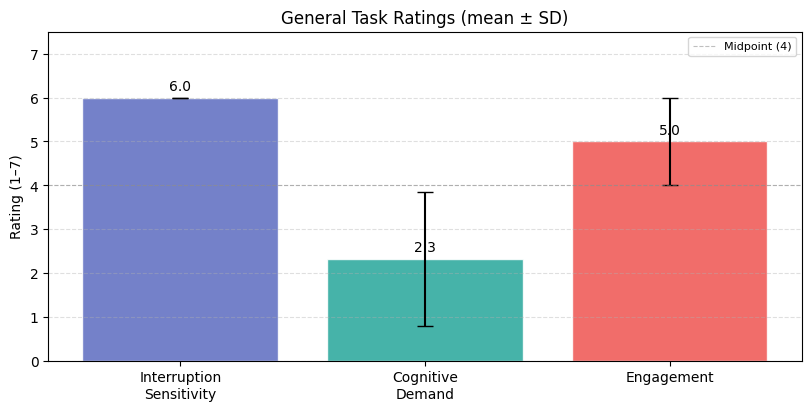

,interruption_sensitivity,cognitive_demand,engagement
count,3.0,3.00,3.0
mean,6.0,2.33,5.0
std,0.0,1.53,1.0
min,6.0,1.00,4.0
25%,6.0,1.50,4.5
50%,6.0,2.00,5.0
75%,6.0,3.00,5.5
max,6.0,4.00,6.0


In [40]:
task_items = {
    'interruption_sensitivity': 'Interruption\nSensitivity',
    'cognitive_demand':         'Cognitive\nDemand',
    'engagement':               'Engagement',
}
task_df = df[list(task_items)].apply(pd.to_numeric, errors='coerce')

fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
means = task_df.mean()
stds  = task_df.std()
labels = [task_items[c] for c in task_df.columns]
colors = ['#5C6BC0', '#26A69A', '#EF5350']

bars = ax.bar(labels, means, yerr=stds if len(df) > 1 else None,
              color=colors, edgecolor='white', capsize=6, alpha=0.85)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10)

ax.set_ylim(0, 7.5)
ax.set_ylabel('Rating (1–7)')
ax.set_title('General Task Ratings (mean ± SD)')
ax.axhline(4, color='gray', lw=0.8, ls='--', alpha=0.5, label='Midpoint (4)')
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.savefig(OUT_DIR / 'survey_task_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

display(task_df.describe().round(2))

## Per-Condition Likert Responses

Each participant rated four conditions on five 1–7 items:
- **Aware**: aware of physical hazards
- **Immersed**: felt present/immersed
- **Disrupted**: safety system disrupted experience
- **Trust**: would trust the system
- **Unfamiliar**: technique felt new/unfamiliar

Section A = Guardian Grid (skipped if it never appeared for that participant).
Sections B–D = the other three conditions in counterbalanced survey order.

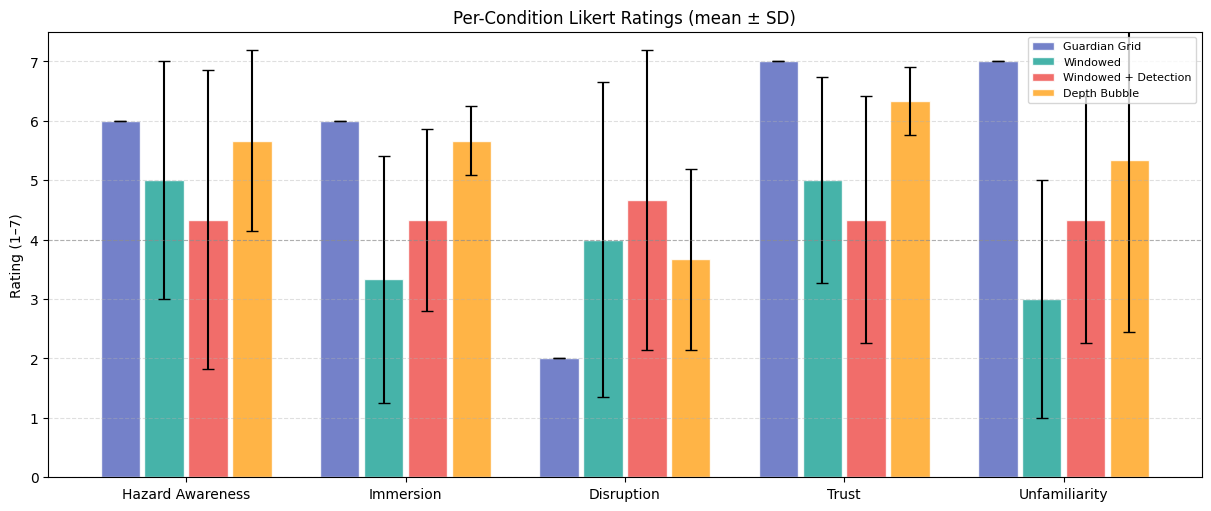

n  mean   std
condition            item                           
Guardian Grid        Hazard Awareness  1  6.00   NaN
                     Immersion         1  6.00   NaN
                     Disruption        1  2.00   NaN
                     Trust             1  7.00   NaN
                     Unfamiliarity     1  7.00   NaN
Windowed             Hazard Awareness  3  5.00  2.00
                     Immersion         3  3.33  2.08
                     Disruption        3  4.00  2.65
                     Trust             3  5.00  1.73
                     Unfamiliarity     3  3.00  2.00
Windowed + Detection Hazard Awareness  3  4.33  2.52
                     Immersion         3  4.33  1.53
                     Disruption        3  4.67  2.52
                     Trust             3  4.33  2.08
                     Unfamiliarity     3  4.33  2.08
Depth Bubble         Hazard Awareness  3  5.67  1.53
                     Immersion         3  5.67  0.58
                     Disruption        3  3.67  1.53
                     Trust             3  6.33  0.58
                     Unfamiliarity     3  5.33  2.89

In [41]:
SECTION_LABELS = {
    'guardian_grid': 'Guardian Grid',
    'cond_b':        'Windowed',
    'cond_c':        'Windowed + Detection',
    'cond_d':        'Depth Bubble',
}
ITEM_LABELS = {
    'aware':      'Hazard Awareness',
    'immersed':   'Immersion',
    'disrupted':  'Disruption',
    'trust':      'Trust',
    'unfamiliar': 'Unfamiliarity',
}
ITEMS = list(ITEM_LABELS)
x = np.arange(len(ITEMS))
w = 0.8 / len(SECTION_LABELS)
colors = ['#5C6BC0', '#26A69A', '#EF5350', '#FFA726']

fig, ax = plt.subplots(figsize=(12, 5), layout='constrained')

for i, (sec, label) in enumerate(SECTION_LABELS.items()):
    means, stds = [], []
    for item in ITEMS:
        col = f'{sec}_{item}'
        vals = df[col].dropna() if col in df.columns else pd.Series([], dtype=float)
        means.append(vals.mean() if not vals.empty else np.nan)
        stds.append(vals.std()   if len(vals) > 1 else 0)
    ax.bar(x + i*w, means,
           yerr=stds if len(df) > 1 else None,
           width=w*0.9, label=label, color=colors[i],
           edgecolor='white', capsize=4, alpha=0.85)

ax.set_xticks(x + w * (len(SECTION_LABELS) - 1) / 2)
ax.set_xticklabels([ITEM_LABELS[i] for i in ITEMS])
ax.set_ylim(0, 7.5)
ax.set_ylabel('Rating (1–7)')
ax.set_title('Per-Condition Likert Ratings (mean ± SD)')
ax.axhline(4, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.savefig(OUT_DIR / 'survey_likert_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
rows = []
for sec, label in SECTION_LABELS.items():
    for item in ITEMS:
        col = f'{sec}_{item}'
        if col not in df.columns:
            continue
        vals = df[col].dropna()
        rows.append({
            'condition': label,
            'item': ITEM_LABELS[item],
            'n': len(vals),
            'mean': vals.mean() if not vals.empty else np.nan,
            'std':  vals.std()  if not vals.empty else np.nan,
        })
summary_likert = pd.DataFrame(rows).set_index(['condition', 'item']).round(2)
display(summary_likert)

## Rankings

Participants ranked all four conditions on three dimensions (1 = best/safest/most trusted / least disruptive).

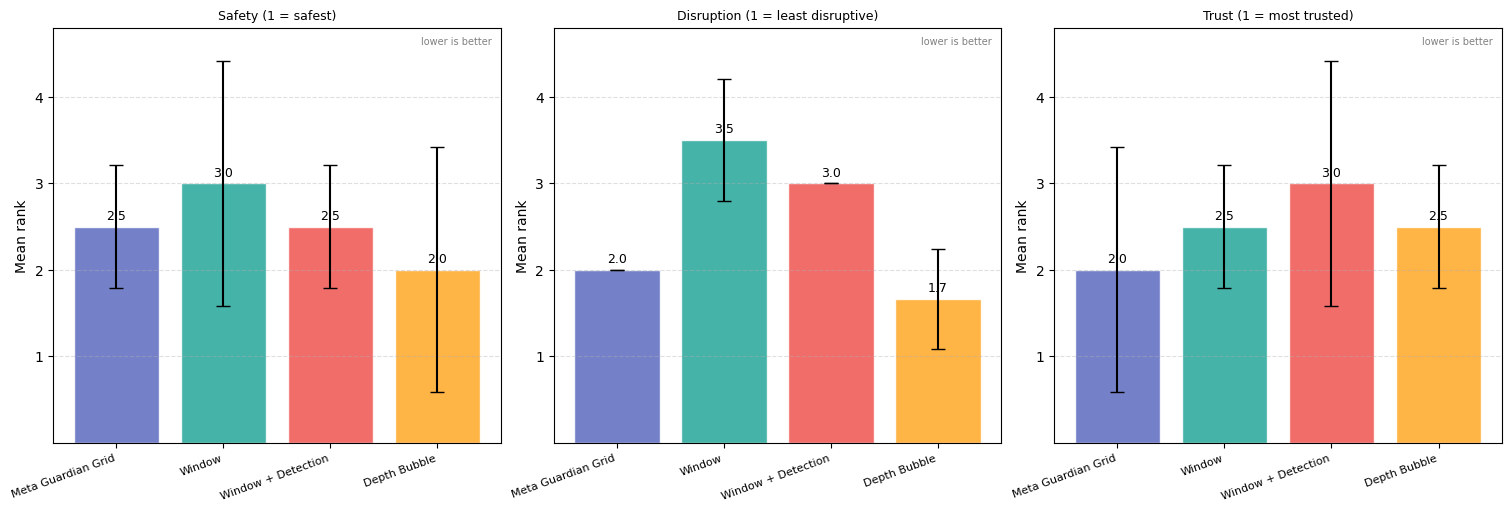

n  mean_rank   std
dimension  condition                             
safety     Meta Guardian Grid  2       2.50  0.71
           Window              2       3.00  1.41
           Window + Detection  2       2.50  0.71
           Depth Bubble        2       2.00  1.41
disruption Meta Guardian Grid  1       2.00   NaN
           Window              2       3.50  0.71
           Window + Detection  2       3.00  0.00
           Depth Bubble        3       1.67  0.58
trust      Meta Guardian Grid  2       2.00  1.41
           Window              2       2.50  0.71
           Window + Detection  2       3.00  1.41
           Depth Bubble        2       2.50  0.71

In [42]:
DIMS = [
    ('safety',     'Safety (1 = safest)',          'lower is better'),
    ('disruption', 'Disruption (1 = least disruptive)', 'lower is better'),
    ('trust',      'Trust (1 = most trusted)',     'lower is better'),
]
cond_keys = {
    'Meta Guardian Grid':  'meta_guardian_grid',
    'Window':              'window',
    'Window + Detection':  'window_plus_detection',
    'Depth Bubble':        'depth_bubble',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), layout='constrained')
colors = ['#5C6BC0', '#26A69A', '#EF5350', '#FFA726']

for ax, (dim, title, note) in zip(axes, DIMS):
    means, stds, labels = [], [], []
    for cond_name, cond_key in cond_keys.items():
        col = f'rank_{dim}_{cond_key}'
        if col not in df.columns:
            continue
        vals = df[col].dropna().astype(float)
        means.append(vals.mean() if not vals.empty else np.nan)
        stds.append(vals.std()   if len(vals) > 1 else 0)
        labels.append(cond_name)

    x = np.arange(len(labels))
    bars = ax.bar(x, means,
                  yerr=stds if len(df) > 1 else None,
                  color=colors[:len(labels)], edgecolor='white', capsize=5, alpha=0.85)
    for bar, val in zip(bars, means):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
    ax.set_ylim(0, 4.8)
    ax.set_yticks([1, 2, 3, 4])
    ax.set_ylabel('Mean rank')
    ax.set_title(title, fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.text(0.98, 0.98, note, transform=ax.transAxes,
            fontsize=7, color='gray', ha='right', va='top')

plt.savefig(OUT_DIR / 'survey_rankings.png', dpi=150, bbox_inches='tight')
plt.show()

# Rank summary table
rank_rows = []
for dim, _, _ in DIMS:
    for cond_name, cond_key in cond_keys.items():
        col = f'rank_{dim}_{cond_key}'
        if col not in df.columns:
            continue
        vals = df[col].dropna().astype(float)
        rank_rows.append({
            'dimension': dim, 'condition': cond_name,
            'n': len(vals),
            'mean_rank': vals.mean() if not vals.empty else np.nan,
            'std': vals.std() if not vals.empty else np.nan,
        })
rank_summary = pd.DataFrame(rank_rows).set_index(['dimension', 'condition']).round(2)
display(rank_summary)

## Free-Text Responses

In [43]:
freetext_cols = [
    ('guardian_grid_freetext', 'Guardian Grid — observations'),
    ('cond_b_freetext',        'Windowed — observations'),
    ('cond_c_freetext',        'Windowed + Detection — observations'),
    ('cond_d_freetext',        'Depth Bubble — observations'),
    ('surprising_room',        'Surprising room / context'),
]

for col, label in freetext_cols:
    if col not in df.columns:
        continue
    vals = df[col].dropna().astype(str).str.strip()
    vals = vals[vals != '']
    if vals.empty:
        continue
    print(f'\n### {label} ({len(vals)} response(s))')
    for i, v in enumerate(vals, 1):
        print(f'  P{i}: {v}')


### Windowed — observations (1 response(s))
  P1: Being centered, it obstructed an important region of my field of view, including making it difficult to read the directional guidance arrow. It was nice to be able to direct my physical view as needed to adjust my positioning, though.

### Windowed + Detection — observations (1 response(s))
  P1: The framerate suffered every few moments as the image detection was running. Since the windows could not update often, they shifted away from whatever they detected as soon as my head turned, so it was difficult to tell what was being detected. Also, many false positives on random objects in my environment.

### Depth Bubble — observations (1 response(s))
  P1: For my play area, the detection threshold was a little too high, so it constantly showed a region of the floor and nearby objects around me in my lower peripheral; however, that wasn't too disruptive, since it was too low in my vision to seriously interfere with my task. Preventing obje

## Export

In [44]:
out = OUT_DIR / 'survey_summary.csv'
summary_likert.to_csv(out)
print(f'Saved -> {out}')

out2 = OUT_DIR / 'survey_rankings.csv'
rank_summary.to_csv(out2)
print(f'Saved -> {out2}')

Saved -> F:\Unity\Projects\DreamGuard\data\analysis\survey_summary.csv
Saved -> F:\Unity\Projects\DreamGuard\data\analysis\survey_rankings.csv
